In [1]:
!pip install ultralytics albumentations opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import shutil
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold

In [3]:
CSV_PATH = "/kaggle/input/datasets/daluanjali/vinbig-ass/Data/train.csv"
IMAGE_PATH = "/kaggle/input/datasets/daluanjali/vinbig-ass/images/train"

WORK_DIR = "/kaggle/working/vinbig_final"

TRAIN_IMG = f"{WORK_DIR}/images/train"
VAL_IMG = f"{WORK_DIR}/images/val"

TRAIN_LABEL = f"{WORK_DIR}/labels/train"
VAL_LABEL = f"{WORK_DIR}/labels/val"

os.makedirs(TRAIN_IMG, exist_ok=True)
os.makedirs(VAL_IMG, exist_ok=True)
os.makedirs(TRAIN_LABEL, exist_ok=True)
os.makedirs(VAL_LABEL, exist_ok=True)

In [4]:
df = pd.read_csv(CSV_PATH)

NO_FINDING_CLASS = 14

In [5]:
df_clean = df.copy()

# Remove invalid boxes
df_clean = df_clean[
    (df_clean["x_max"] > df_clean["x_min"]) &
    (df_clean["y_max"] > df_clean["y_min"])
]

# Remove NaNs
df_clean = df_clean.dropna(subset=["x_min", "y_min", "x_max", "y_max"])

# Remove duplicates (IMPORTANT FIX)
df_clean = df_clean.drop_duplicates(
    subset=["image_id", "class_id", "x_min", "y_min", "x_max", "y_max"]
)

In [6]:
all_image_ids = df["image_id"].unique()

In [7]:
image_labels = df.groupby("image_id")["class_id"].apply(
    lambda x: -1 if (x == NO_FINDING_CLASS).all() else x.mode()[0]
)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
train_idx, val_idx = next(skf.split(image_labels.index, image_labels.values))

train_ids = image_labels.index[train_idx]
val_ids = image_labels.index[val_idx]

In [8]:
def create_labels(image_ids, label_dir, img_dir):

    for image_id in tqdm(image_ids):

        img_path = f"{IMAGE_PATH}/{image_id}.jpg"
        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        rows = df_clean[df_clean["image_id"] == image_id]

        labels = []

        for _, r in rows.iterrows():

            cls = int(r["class_id"])

            # ❗ Skip "No finding"
            if cls == NO_FINDING_CLASS:
                continue

            x_min, y_min, x_max, y_max = r["x_min"], r["y_min"], r["x_max"], r["y_max"]

            x_center = ((x_min + x_max) / 2) / w
            y_center = ((y_min + y_max) / 2) / h
            width = (x_max - x_min) / w
            height = (y_max - y_min) / h

            # clip
            x_center = np.clip(x_center, 0, 1)
            y_center = np.clip(y_center, 0, 1)
            width = np.clip(width, 1e-4, 1)
            height = np.clip(height, 1e-4, 1)

            labels.append(
                f"{cls} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
            )

        label_path = f"{label_dir}/{image_id}.txt"

        if len(labels) > 0:
            with open(label_path, "w") as f:
                f.write("\n".join(labels))
        else:
            # ✅ NORMAL IMAGE → EMPTY FILE
            open(label_path, "w").close()

        shutil.copy(img_path, img_dir)

In [13]:
create_labels(train_ids, TRAIN_LABEL, TRAIN_IMG)
create_labels(val_ids, VAL_LABEL, VAL_IMG)

100%|██████████| 1500/1500 [00:15<00:00, 94.77it/s]


In [14]:
import os

empty, non_empty = 0, 0

for f in os.listdir(TRAIN_LABEL):
    if os.path.getsize(f"{TRAIN_LABEL}/{f}") == 0:
        empty += 1
    else:
        non_empty += 1

print("Empty labels:", empty)
print("Non-empty labels:", non_empty)


Empty labels: 9545
Non-empty labels: 3955


In [15]:
yaml_content = f"""
path: {WORK_DIR}

train: images/train
val: images/val

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""
with open(f"{WORK_DIR}/vinbig.yaml", "w") as f:
    f.write(yaml_content)

In [17]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data=f"{WORK_DIR}/vinbig.yaml",
    epochs=25,
    imgsz=640,
    batch=8,
    device=0,
    workers=4,

    lr0=0.003,
    lrf=0.1,

    augment=True,
    mosaic=1.0,
    mixup=0.1,

    cos_lr=True,
    patience=20,
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/vinbig_final/vinbig.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d9e68d4bfb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [18]:
metrics = model.val(
    data=f"{WORK_DIR}/vinbig.yaml",
    split="val",
    imgsz=640,
    batch=16,
    device=0
)

print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 687.4±208.8 MB/s, size: 27.5 KB)
val: Scanning /kaggle/working/vinbig_final/labels/val.cache... 1500 images, 1061 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1500/1500 629.1Mit/s 0.0s
val: /kaggle/working/vinbig_final/images/val/01fec681f2d698497151a88d6c5205a1.jpg: 2 duplicate labels removed
val: /kaggle/working/vinbig_final/images/val/024f9140bd829c346fc91fcf4009d251.jpg: 11 duplicate labels removed
val: /kaggle/working/vinbig_final/images/val/02de1ec3340e75fd5e7294a84a0342a1.jpg: 4 duplicate labels removed
val: /kaggle/working/vinbig_final/images/val/038a7c88fcd819549f430c1fd907658c.jpg: 3 duplicate labels removed
val: /kaggle/working/vinbig_final/images/val/04bb8bd7ee6f88a16623fe5c6dd4da91.jpg: 6 duplicate labels removed
val: /kaggle/working/vinbig_final/images/val/04fbba5

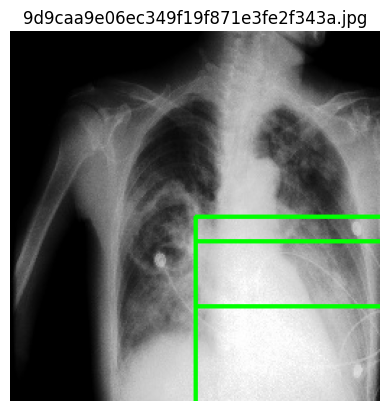

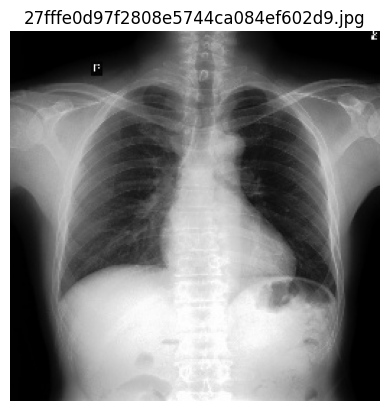

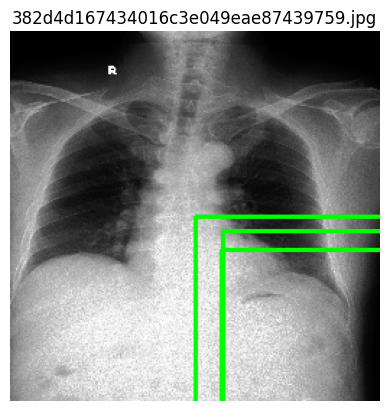

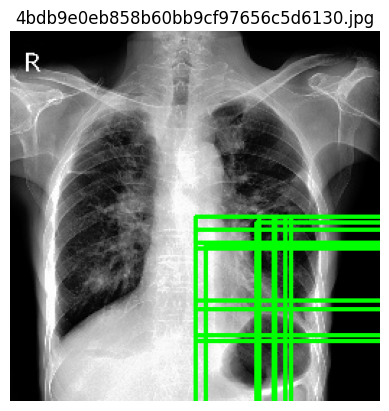

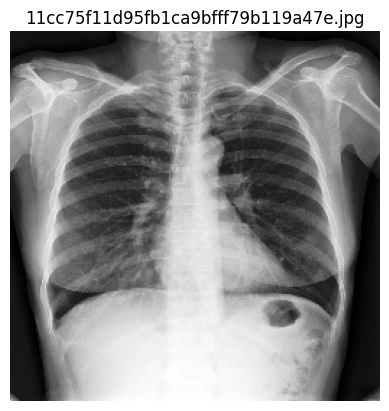

In [19]:
import random
import matplotlib.pyplot as plt

samples = random.sample(os.listdir(TRAIN_IMG), 5)

for sample in samples:
    img = cv2.imread(f"{TRAIN_IMG}/{sample}")
    h, w = img.shape[:2]

    label_path = f"{TRAIN_LABEL}/{sample.replace('.jpg','.txt')}"

    if not os.path.exists(label_path):
        continue

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.split())

            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.imshow(img)
    plt.title(sample)
    plt.axis("off")
    plt.show()